In [31]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [32]:
# ================================================================
# HELPER FUNCTIONS
# ================================================================

def norm_cdf(x): return norm.cdf(x)
def norm_ppf(x): return norm.ppf(x)

LGD = 0.60        # ISDA standard for sovereign CDS
T   = 5.0         # 5-year horizon (matches 5Y CDS)


def pd_to_cds_spread(pd_val, T=T, lgd=LGD):
    """PD → approximate CDS spread in bps."""
    pd_c = np.clip(pd_val, 1e-12, 1 - 1e-6)
    return -(1.0 / T) * np.log(1.0 - lgd * pd_c) * 10000


def merton_pd_cf(V0, B0, sigma, mu, T=T):
    """Closed-form Merton PD and DD."""
    denom = np.maximum(sigma * np.sqrt(T), 1e-10)
    dd = (np.log(V0 / B0) + (mu - 0.5 * sigma**2) * T) / denom
    pd = norm.cdf(-dd)
    return pd, dd


# ================================================================
# ROLLING CALIBRATION
# ================================================================

def _calibrate_window(B0, sigma, mu, cds_obs, T=T, lgd=LGD,
                      scale_bounds=(1.01, 10.0)):
    """
    Find scale_mult for a window so M1's avg implied spread
    matches the avg observed CDS spread.
    Returns (scale, status_str).
    """
    valid = (~np.isnan(B0) & ~np.isnan(sigma) & ~np.isnan(mu) &
             ~np.isnan(cds_obs) & (B0 > 0) & (sigma > 0) & (cds_obs > 0))
    B0_v, sig_v, mu_v, cds_v = B0[valid], sigma[valid], mu[valid], cds_obs[valid]

    if len(B0_v) < 10:
        return None, 'insufficient_data'

    target = np.mean(cds_v)

    def err(s):
        pd_vals, _ = merton_pd_cf(s * B0_v, B0_v, sig_v, mu_v, T)
        return np.mean(pd_to_cds_spread(pd_vals, T, lgd)) - target

    try:
        e_lo, e_hi = err(scale_bounds[0]), err(scale_bounds[1])
    except Exception:
        return None, 'eval_failed'

    if e_lo < 0:
        return scale_bounds[0], 'at_lower_bound'
    if e_hi > 0:
        return scale_bounds[1], 'at_upper_bound'

    try:
        return brentq(err, scale_bounds[0], scale_bounds[1],
                      xtol=1e-4, maxiter=100), 'converged'
    except Exception:
        return None, 'brentq_failed'


def calibrate_rolling(df, cds_col='cds_spread',
                      barrier_col='default_barrier',
                      sigma_col='msci_vol_annual',
                      country_col='country_clean',
                      mu_mode='zero',
                      window_weeks=52,
                      min_obs=26,
                      T=T, lgd=LGD,
                      scale_bounds=(1.01, 10.0)):
    """
    Rolling calibration: at each week t, find scale_mult using
    the trailing window so M1's avg implied spread ≈ avg CDS.
    
    Handles structural breaks naturally.
    """
    df_out = df.copy()
    df_out['scale_mult'] = np.nan

    print(f'Rolling calibration: window={window_weeks}w, '
          f'min_obs={min_obs}, LGD={lgd}')

    for country in sorted(df_out[country_col].unique()):
        mask = df_out[country_col] == country
        idx = df_out.loc[mask].index

        B0_all  = df_out.loc[mask, barrier_col].values
        sig_all = df_out.loc[mask, sigma_col].values
        cds_all = df_out.loc[mask, cds_col].values
        mu_all  = np.zeros(len(idx))

        n = len(idx)
        last_good = None
        conv = 0

        for t in range(n):
            start = max(0, t - window_weeks + 1)
            if t - start + 1 < min_obs:
                if last_good is not None:
                    df_out.loc[idx[t], 'scale_mult'] = last_good
                continue

            scale, status = _calibrate_window(
                B0_all[start:t+1], sig_all[start:t+1],
                mu_all[start:t+1], cds_all[start:t+1],
                T, lgd, scale_bounds)

            if scale is not None:
                df_out.loc[idx[t], 'scale_mult'] = scale
                last_good = scale
                if status == 'converged': conv += 1
            elif last_good is not None:
                df_out.loc[idx[t], 'scale_mult'] = last_good

        # Fill edges
        s = df_out.loc[mask, 'scale_mult']
        df_out.loc[mask, 'scale_mult'] = s.ffill().bfill()

        scales = df_out.loc[mask, 'scale_mult'].dropna()
        print(f'  {country:<20s}  scale: {scales.mean():.2f} '
              f'[{scales.min():.2f}–{scales.max():.2f}]  conv={conv}/{n}')

    return df_out

# ================================================================
# ROLLING CALIBRATION FOR JUMP MODELS (MC-based)
# ================================================================

def _calibrate_window_mc(B0, sigma, mu, cds_obs, lam, theta, delta,
                         T=5.0, lgd=0.6, scale_bounds=(1.01, 10.0),
                         n_paths_cal=5000, seed=99):
    """Find scale_mult for a window so MC-model avg spread ≈ avg CDS."""
    valid = (~np.isnan(B0) & ~np.isnan(sigma) & ~np.isnan(cds_obs)
             & (B0 > 0) & (sigma > 0) & (cds_obs > 0))
    B0_v = B0[valid]; sig_v = sigma[valid]; mu_v = mu[valid]
    cds_v = cds_obs[valid]; lam_v = lam[valid]
    th_v = theta[valid]; de_v = delta[valid]

    if len(B0_v) < 10:
        return None, 'insufficient_data'

    target = np.mean(cds_v)

    def err(s):
        V0_try = s * B0_v
        pd_vals, _, _ = mc_pd_dd_jump_stochastic(
            V0_try, B0_v, sig_v, mu_v, lam_v, th_v, de_v,
            T=T, n_paths=n_paths_cal, seed=seed)
        return np.mean(pd_to_cds_spread(pd_vals, T, lgd)) - target

    try:
        e_lo, e_hi = err(scale_bounds[0]), err(scale_bounds[1])
    except Exception:
        return None, 'eval_failed'
    if e_lo < 0: return scale_bounds[0], 'at_lower_bound'
    if e_hi > 0: return scale_bounds[1], 'at_upper_bound'
    try:
        return brentq(err, scale_bounds[0], scale_bounds[1],
                      xtol=1e-3, maxiter=50), 'converged'
    except Exception:
        return None, 'brentq_failed'


def calibrate_rolling_mc(df, lam_col, theta_col='theta', delta_col='delta',
                         cds_col='cds_spread',
                         barrier_col='default_barrier',
                         sigma_col='msci_vol_annual',
                         country_col='country_clean',
                         window_weeks=52, min_obs=26,
                         n_paths_cal=5000, seed=99,
                         scale_col_out='scale_mult_mc'):
    """Rolling calibration for a jump model (MC-based)."""
    df[scale_col_out] = np.nan
    for country in sorted(df[country_col].unique()):
        mask = df[country_col] == country
        idx = df.loc[mask].index
        B0_a  = df.loc[mask, barrier_col].values
        sig_a = df.loc[mask, sigma_col].values
        cds_a = df.loc[mask, cds_col].values
        mu_a  = np.zeros(len(idx))
        lam_a = df.loc[mask, lam_col].values
        th_a  = df.loc[mask, theta_col].values
        de_a  = df.loc[mask, delta_col].values
        n = len(idx); last_good = None; conv = 0
        for t in range(n):
            start = max(0, t - window_weeks + 1)
            if t - start + 1 < min_obs:
                if last_good is not None:
                    df.loc[idx[t], scale_col_out] = last_good
                continue
            sl = slice(start, t+1)
            scale, status = _calibrate_window_mc(
                B0_a[sl], sig_a[sl], mu_a[sl], cds_a[sl],
                lam_a[sl], th_a[sl], de_a[sl],
                n_paths_cal=n_paths_cal, seed=seed)
            if scale is not None:
                df.loc[idx[t], scale_col_out] = scale
                last_good = scale
                if status == 'converged': conv += 1
            elif last_good is not None:
                df.loc[idx[t], scale_col_out] = last_good
        s = df.loc[mask, scale_col_out]
        df.loc[mask, scale_col_out] = s.ffill().bfill()
        scales = df.loc[mask, scale_col_out].dropna()
        print(f'  {country:<20s}  {scale_col_out}: {scales.mean():.2f} '
              f'[{scales.min():.2f}-{scales.max():.2f}]  conv={conv}/{n}')
    return df


In [33]:
# ================================================================
# TWO-PHASE MONTE CARLO (same as before)
# ================================================================

def mc_two_phase(V0, B0, sigma, mu, lam, theta, delta,
                 T=5.0, T_jump=4/52, n_paths=20000, seed=7):
    """
    Phase 1 [0, T_jump]: jump-diffusion (lam, theta, delta)
    Phase 2 [T_jump, T]: pure GBM
    """
    rng = np.random.default_rng(seed)
    n_obs = len(V0)
    T_diff = T - T_jump

    # Phase 1
    drift_1 = (mu - 0.5 * sigma**2) * T_jump
    vol_1   = sigma * np.sqrt(T_jump)
    Z1 = rng.standard_normal((n_obs, n_paths))

    N = rng.poisson(lam[:, None] * T_jump, size=(n_obs, n_paths))
    agg_mean = N * theta[:, None]
    agg_std  = np.sqrt(np.maximum(N, 0)) * delta[:, None]
    Z_jump   = rng.standard_normal((n_obs, n_paths))
    total_jump = np.minimum(agg_mean + agg_std * Z_jump, 0.0)

    logV_phase1 = (np.log(V0)[:, None]
                   + drift_1[:, None]
                   + vol_1[:, None] * Z1
                   + total_jump)

    # Phase 2
    drift_2 = (mu - 0.5 * sigma**2) * T_diff
    vol_2   = sigma * np.sqrt(T_diff)
    Z2 = rng.standard_normal((n_obs, n_paths))

    logVT = logV_phase1 + drift_2[:, None] + vol_2[:, None] * Z2

    PD = (logVT < np.log(B0)[:, None]).mean(axis=1)
    DD = norm_ppf(1 - np.clip(PD, 1e-10, 1 - 1e-10))
    SE = np.sqrt(PD * (1 - PD) / n_paths)

    return PD, DD, SE


# ================================================================
# RATING -> PD -> V0/B0 CALIBRATION
# ================================================================

# S&P 5-year cumulative sovereign default rates (approx)
RATING_PD_5Y = {
    'AAA': 0.0001, 'AA+': 0.0003, 'AA': 0.0005, 'AA-': 0.001,
    'A+': 0.002, 'A': 0.004, 'A-': 0.006,
    'BBB+': 0.01, 'BBB': 0.02, 'BBB-': 0.04,
    'BB+': 0.06, 'BB': 0.08, 'BB-': 0.12,
    'B+': 0.17, 'B': 0.22, 'B-': 0.28,
    'CCC+': 0.40, 'CCC': 0.50, 'CC': 0.65,
}

def rating_to_scale(rating, sigma, mu=0.0, T=5.0):
    """Invert Merton to get V0/B0 from rating-implied PD."""
    pd_target = RATING_PD_5Y.get(rating)
    if pd_target is None or pd_target <= 0:
        return np.nan
    dd_target = -norm.ppf(pd_target)
    return np.exp(dd_target * sigma * np.sqrt(T) + (mu + 0.5 * sigma**2) * T)


# ================================================================
# MAIN RUNNER
# ================================================================

def run_all_models(panel_csv, ratings_csv, out_csv,
                   mu_mode='zero',
                   ovx_thresholds=(30, 50),
                   ovx_lambdas=(0.3, 1.1, 2.9),
                   T_jump_weeks=4,
                   n_paths=50000):
    """
    Pipeline:
      1. Load panel + ratings
      2. Calibrate V0/B0 from S&P rating (static, per country)
      3. Run M1 (closed-form GBM) on full sample
      4. Run M3 (two-phase: OVX jump + GBM) on full sample
      5. Identify OVX stress episodes and compare performance
    """
    df = pd.read_csv(panel_csv, parse_dates=['date'])
    ratings = pd.read_csv(ratings_csv)

    # --- Oil exporter classification ---
    OIL_EXPORTERS = ['Saudi Arabia', 'United Arab Emirates', 'Qatar',
                     'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia']
    CONTROLS      = ['Indonesia', 'Philippines', 'Turkey', 'Chile',
                     'China', 'South Africa', 'South Korea', 'Thailand']
    _oil_set  = {c.lower() for c in OIL_EXPORTERS}
    _ctrl_set = {c.lower() for c in CONTROLS}
    df['oil_exporter'] = df['country_clean'].str.lower().apply(
        lambda x: 1 if x in _oil_set else (0 if x in _ctrl_set else np.nan))

    # --- Merge ratings ---
    rating_map = dict(zip(ratings['Country'].str.lower(),
                          ratings['CreditRating_SPGlobalRatings']))
    df['sp_rating'] = df['country_clean'].str.lower().map(rating_map)

    # --- Rating-based V0/B0 calibration ---
    print('=' * 60)
    print('  RATING-BASED CALIBRATION')
    print('=' * 60)

    # Use per-row sigma for calibration (time-varying scale)
    df['scale_rating'] = df.apply(
        lambda row: rating_to_scale(row['sp_rating'],
                                     row['msci_vol_annual'])
        if pd.notna(row['sp_rating']) and row['msci_vol_annual'] > 0
        else np.nan, axis=1)

    # Report
    for c in sorted(df['country_clean'].unique()):
        sub = df[df['country_clean'] == c]
        r = sub['sp_rating'].iloc[0] if pd.notna(sub['sp_rating'].iloc[0]) else '?'
        s = sub['scale_rating'].dropna()
        if len(s) > 0:
            print(f'  {c:<22s}  {r:<5s}  scale: {s.mean():.2f} '
                  f'[{s.min():.2f}-{s.max():.2f}]')
        else:
            print(f'  {c:<22s}  {r:<5s}  NO VALID SCALE')

    n_before = len(df)
    df = df.dropna(subset=['scale_rating']).copy()
    print(f'\n  Kept {len(df)}/{n_before} rows with valid scale')

    # --- Build arrays ---
    sigma = df['msci_vol_annual'].values
    B0    = df['default_barrier'].values
    V0    = df['scale_rating'].values * B0
    theta = df['theta'].values
    delta = df['delta'].values
    ovx   = df['OVX'].values
    mu    = np.zeros(len(df))

    T_jump = T_jump_weeks / 52.0

    # ---- M1: Baseline Merton ----
    print('\n' + '=' * 60)
    print('  RUNNING MODELS')
    print('=' * 60)
    pd_m1, dd_m1 = merton_pd_cf(V0, B0, sigma, mu)

    # ---- Lambda arrays ----
    low_t, high_t = ovx_thresholds
    lam_calm, lam_elev, lam_stress = ovx_lambdas
    lam_ovx = np.where(
        ovx < low_t, lam_calm,
        np.where(ovx < high_t, lam_elev, lam_stress))
    df['lam_ovx'] = lam_ovx

    # ---- M3: Two-phase with OVX lambda ----
    print(f'  Running M3 (T_jump={T_jump_weeks}wk, lam={ovx_lambdas})...')
    pd_m3, dd_m3, _ = mc_two_phase(
        V0, B0, sigma, mu, lam_ovx, theta, delta,
        T=T, T_jump=T_jump, n_paths=n_paths, seed=22)

    # ---- Store ----
    df['pd_m1']  = pd_m1;  df['dd_m1']  = dd_m1
    df['pd_m3']  = pd_m3;  df['dd_m3']  = dd_m3
    df['spread_m1'] = pd_to_cds_spread(pd_m1)
    df['spread_m3'] = pd_to_cds_spread(pd_m3)
    df['dd_diff']   = dd_m3 - dd_m1

    # ---- Full-sample summary ----
    print(f'\n{"="*60}')
    print('  FULL-SAMPLE SUMMARY')
    print('=' * 60)
    obs = df['cds_spread']
    for label, col in [('M1 (GBM)', 'spread_m1'), ('M3 (OVX jumps)', 'spread_m3')]:
        impl = df[col]
        corr = obs.corr(impl)
        rmse = np.sqrt(np.mean((obs - impl)**2))
        print(f'  {label:<18s}  mean={impl.mean():7.0f}bps  '
              f'corr={corr:.3f}  rmse={rmse:.0f}bps')
    print(f'  {"Observed":<18s}  mean={obs.mean():7.0f}bps')

    df.to_csv(out_csv, index=False)
    print(f'\n  Saved to {out_csv}')
    return df


In [34]:
in_path     = 'data/processed/structural_model_panel_built.csv'
ratings_path = 'data/processed/Macroeconomic_variables/credit-rating-by-country-2026.csv'
out_path     = 'output/mc_calibrated_results.csv'

df_res = run_all_models(
    panel_csv=in_path,
    ratings_csv=ratings_path,
    out_csv=out_path,
    mu_mode='zero',
    ovx_thresholds=(30, 50),
    ovx_lambdas=(0.3, 50, 2.9),
    T_jump_weeks=4,
    n_paths=10000,
)

  RATING-BASED CALIBRATION
  brazil                  BB     scale: 3.96 [1.80-13.24]
  chile                   A      scale: 6.53 [2.44-23.72]
  china                   A+     scale: 5.48 [2.35-12.05]
  colombia                BB+    scale: 6.06 [1.77-41.81]
  czechia                 AA-    scale: 6.78 [1.97-32.12]
  egypt                   B-     scale: 2.05 [1.28-5.81]
  greece                  BBB-   scale: 6.97 [2.13-38.26]
  hungary                 BBB-   scale: 3.95 [1.86-12.33]
  india                   BBB-   scale: 2.24 [1.53-4.60]
  indonesia               BBB    scale: 3.82 [1.54-14.92]
  malaysia                A-     scale: 2.24 [1.46-4.41]
  mexico                  BBB    scale: 3.70 [1.99-12.03]
  peru                    BBB    scale: 4.34 [2.19-9.44]
  philippines             BBB+   scale: 3.32 [1.73-11.63]
  poland                  A-     scale: 5.89 [2.59-25.69]
  saudi arabia            A      scale: 3.10 [2.05-5.91]
  south africa            BB-    scale: 2.73 [1.58

In [35]:
country = 'brazil'   # <-- change here

df_c = (df_res[df_res['country_clean'].str.lower() == country.lower()]
        .sort_values('date').copy())

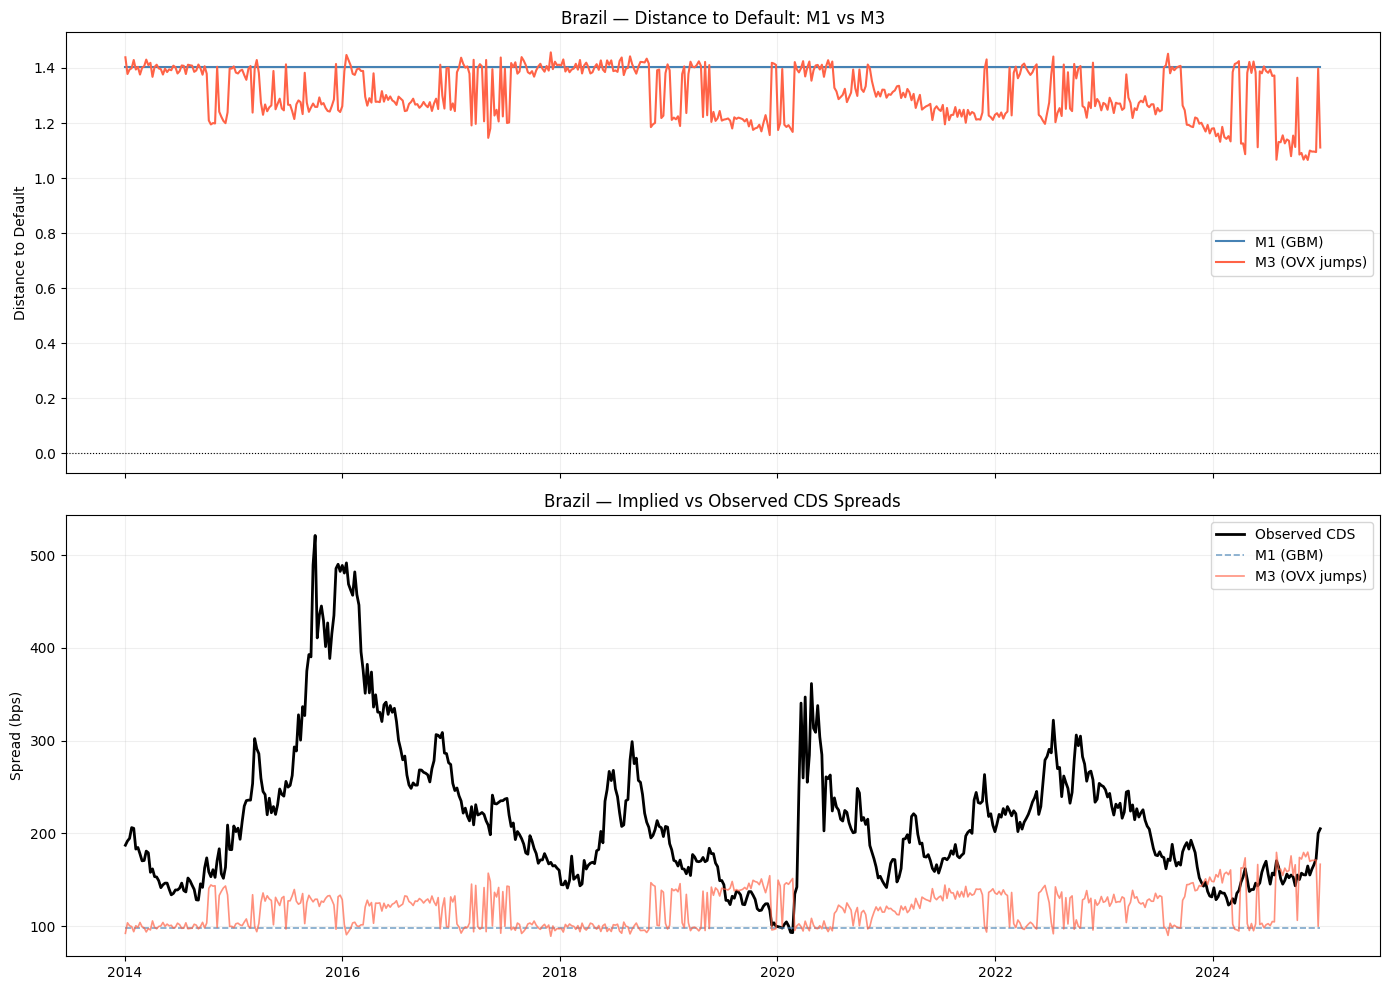

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Top: Distance-to-Default ---
ax = axes[0]
ax.plot(df_c['date'], df_c['dd_m1'], label='M1 (GBM)', color='steelblue', lw=1.5)
ax.plot(df_c['date'], df_c['dd_m3'], label='M3 (OVX jumps)', color='tomato', lw=1.5)
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_ylabel('Distance to Default')
ax.set_title(f'{country.title()} — Distance to Default: M1 vs M3')
ax.legend()
ax.grid(True, alpha=0.2)

# --- Bottom: Implied spreads vs observed ---
ax = axes[1]
ax.plot(df_c['date'], df_c['cds_spread'], label='Observed CDS', color='black', lw=2)
ax.plot(df_c['date'], df_c['spread_m1'], label='M1 (GBM)', color='steelblue',
        lw=1.2, alpha=0.7, ls='--')
ax.plot(df_c['date'], df_c['spread_m3'], label='M3 (OVX jumps)', color='tomato',
        lw=1.2, alpha=0.7)
ax.set_ylabel('Spread (bps)')
ax.set_title(f'{country.title()} — Implied vs Observed CDS Spreads')
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


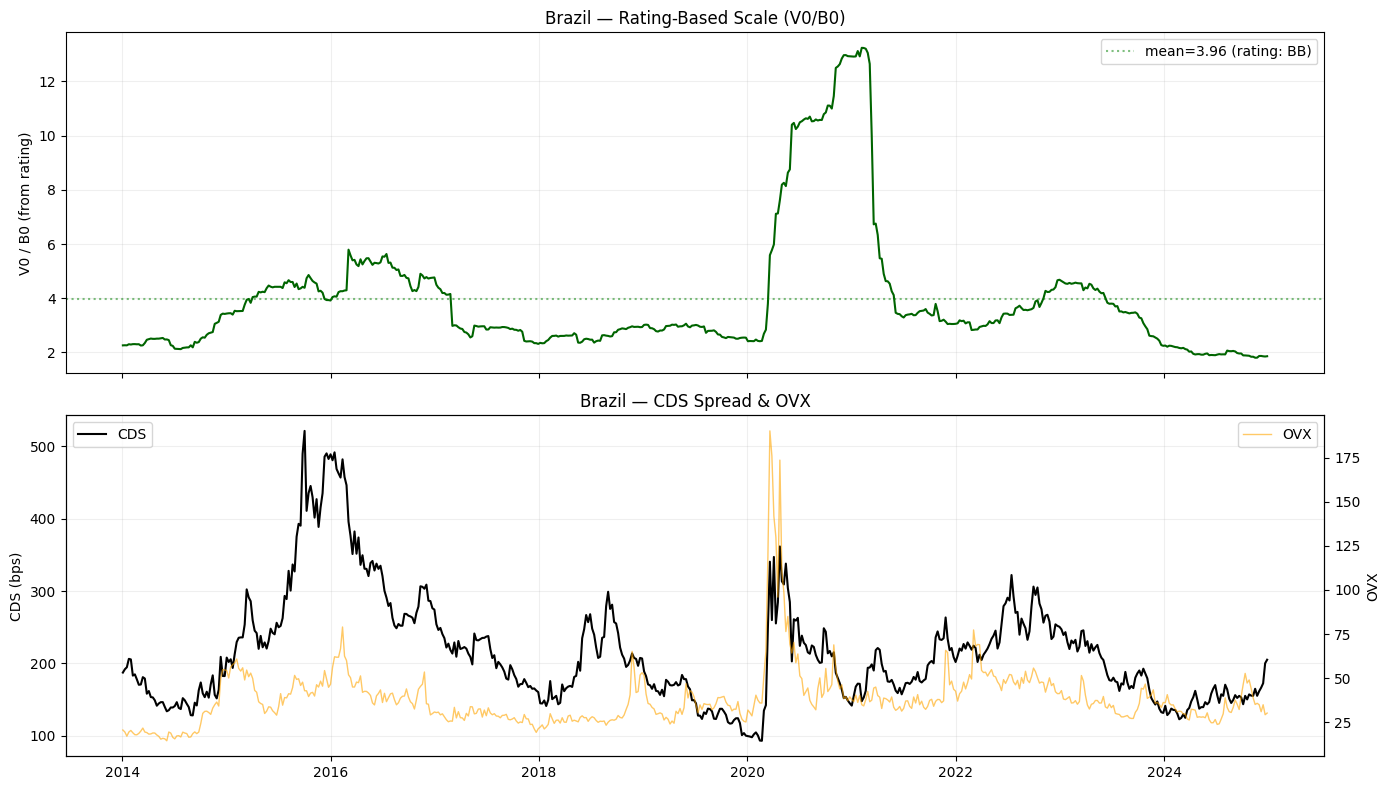

In [37]:
# Calibration diagnostic: how does scale_rating compare across countries?
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(df_c['date'], df_c['scale_rating'], color='darkgreen', lw=1.5)
ax.set_ylabel('V0 / B0 (from rating)')
ax.set_title(f'{country.title()} — Rating-Based Scale (V0/B0)')
ax.grid(True, alpha=0.2)
rating = df_c['sp_rating'].iloc[0] if 'sp_rating' in df_c.columns else '?'
ax.axhline(df_c['scale_rating'].mean(), color='green', ls=':', alpha=0.5,
           label=f'mean={df_c["scale_rating"].mean():.2f} (rating: {rating})')
ax.legend()

ax = axes[1]
ax.plot(df_c['date'], df_c['cds_spread'], color='black', lw=1.5, label='CDS')
ax2 = ax.twinx()
ax2.plot(df_c['date'], df_c['OVX'], color='orange', lw=1, alpha=0.6, label='OVX')
ax.set_ylabel('CDS (bps)')
ax2.set_ylabel('OVX')
ax.set_title(f'{country.title()} — CDS Spread & OVX')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [38]:
import statsmodels.api as sm

def run_reg(x, y):
    X = sm.add_constant(x)
    return sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'=== {country.title()} — Level Regression: spread_model vs CDS ===\n')

obs = df_c['cds_spread'].values
for label, col in [('M1 (GBM)', 'spread_m1'), ('M3 (OVX jumps)', 'spread_m3')]:
    impl = df_c[col].values
    valid = ~np.isnan(obs) & ~np.isnan(impl)
    if valid.sum() < 30:
        continue
    reg = run_reg(impl[valid], obs[valid])
    print(f'  {label:<18s}  R2={reg.rsquared:.4f}  '
          f'beta={reg.params[1]:.3f}  t={reg.tvalues[1]:.2f}  '
          f'N={int(reg.nobs)}')


=== Brazil — Level Regression: spread_model vs CDS ===

  M1 (GBM)            R2=0.0000  beta=2.179  t=30.87  N=574
  M3 (OVX jumps)      R2=0.0179  beta=-0.491  t=-2.16  N=574


In [39]:
# ================================================================
# CHANGE-ON-CHANGE REGRESSION (single country)
# ================================================================
# dCDS(t) = a + b * dSpread_model(t) + e
# Compares how well M1 vs M3 track weekly CDS moves.
# HAC (Newey-West) standard errors with 4 lags.
# ================================================================

def change_on_change_reg(df_country, country_label=''):
    dc = df_country.sort_values('date').copy()
    dc['d_cds']       = dc['cds_spread'].diff()
    dc['d_spread_m1'] = dc['spread_m1'].diff()
    dc['d_spread_m3'] = dc['spread_m3'].diff()

    print(f'=== {country_label} — Change-on-Change ===')
    print(f'  dCDS(t) = a + b * dSpread(t) + e\n')

    results = {}
    for label, dcol in [('M1 (GBM)', 'd_spread_m1'),
                         ('M3 (OVX jumps)', 'd_spread_m3')]:
        tmp = dc[['d_cds', dcol]].dropna()
        if len(tmp) < 30:
            continue
        y = tmp['d_cds'].values
        X = sm.add_constant(tmp[dcol].values)
        reg = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

        sig = '***' if reg.pvalues[1] < 0.01 else '**' if reg.pvalues[1] < 0.05 else '*' if reg.pvalues[1] < 0.1 else ''
        print(f'  {label:<18s}  R2={reg.rsquared:.4f}  '
              f'beta={reg.params[1]:.3f}  t={reg.tvalues[1]:.2f}  '
              f'p={reg.pvalues[1]:.3f} {sig}  N={int(reg.nobs)}')
        results[label] = {'R2': reg.rsquared, 'beta': reg.params[1]}

    if 'M1 (GBM)' in results and 'M3 (OVX jumps)' in results:
        gain = results['M3 (OVX jumps)']['R2'] - results['M1 (GBM)']['R2']
        print(f'\n  R2 gain (M3 - M1): {gain:+.4f}')
    return results

res = change_on_change_reg(df_c, country_label=country.title())


=== Brazil — Change-on-Change ===
  dCDS(t) = a + b * dSpread(t) + e

  M1 (GBM)            R2=0.0007  beta=-3132569039964.169  t=-0.64  p=0.520   N=573
  M3 (OVX jumps)      R2=0.0033  beta=-0.060  t=-1.36  p=0.175   N=573

  R2 gain (M3 - M1): +0.0026


In [40]:
# ================================================================
# PANEL: Change-on-Change R² by Country + DiD Test
# ================================================================

df_panel = df_res.sort_values(['country_clean', 'date']).copy()
df_panel['d_cds']       = df_panel.groupby('country_clean')['cds_spread'].diff()
df_panel['d_spread_m1'] = df_panel.groupby('country_clean')['spread_m1'].diff()
df_panel['d_spread_m3'] = df_panel.groupby('country_clean')['spread_m3'].diff()

print('Change-on-Change R² by Country')
print('=' * 75)
print(f'{"Country":<20s} {"Oil":>3s} {"R2_M1":>7s} {"R2_M3":>7s} {"gain":>8s}')
print('-' * 75)

cc_rows = []
for ctry in sorted(df_panel['country_clean'].unique()):
    dc = df_panel[df_panel['country_clean'] == ctry]
    oil = dc['oil_exporter'].iloc[0]
    row = {'country': ctry, 'oil_exporter': oil}

    for model, dcol in [('M1', 'd_spread_m1'), ('M3', 'd_spread_m3')]:
        tmp = dc[['d_cds', dcol]].dropna()
        if len(tmp) < 30:
            row[f'R2_{model}'] = np.nan
            continue
        y = tmp['d_cds'].values
        X = sm.add_constant(tmp[dcol].values)
        reg = sm.OLS(y, X).fit()
        row[f'R2_{model}'] = reg.rsquared

    row['R2_gain'] = (row.get('R2_M3', np.nan) or np.nan) - (row.get('R2_M1', np.nan) or np.nan)
    cc_rows.append(row)

    tag = 'OIL' if oil == 1 else 'CTL'
    g = f'{row["R2_gain"]:>+8.4f}' if not np.isnan(row.get('R2_gain', np.nan)) else '      --'
    r1 = f'{row.get("R2_M1", np.nan):>7.4f}' if not np.isnan(row.get('R2_M1', np.nan)) else '     --'
    r3 = f'{row.get("R2_M3", np.nan):>7.4f}' if not np.isnan(row.get('R2_M3', np.nan)) else '     --'
    print(f'  {ctry:<20s} [{tag}] {r1} {r3} {g}')

cc_df = pd.DataFrame(cc_rows)

print('\n' + '-' * 75)
for grp, label in [(1, 'Oil Exporters'), (0, 'Controls')]:
    sub = cc_df[cc_df['oil_exporter'] == grp]
    avg = sub['R2_gain'].mean()
    pos = (sub['R2_gain'] > 0).sum()
    print(f'  {label} (n={len(sub)}):  avg R2 gain = {avg:+.4f}  positive: {pos}/{len(sub)}')

oil_g  = cc_df[cc_df['oil_exporter']==1]['R2_gain'].mean()
ctrl_g = cc_df[cc_df['oil_exporter']==0]['R2_gain'].mean()
print(f'\n  DiD: {oil_g:+.4f} (oil) - {ctrl_g:+.4f} (ctrl) = {oil_g - ctrl_g:+.4f}')


Change-on-Change R² by Country
Country              Oil   R2_M1   R2_M3     gain
---------------------------------------------------------------------------
  brazil               [OIL]  0.0007  0.0033  +0.0026
  chile                [CTL]  0.0000  0.0016  +0.0016
  china                [CTL]  0.0000  0.0012  +0.0012
  colombia             [OIL]  0.0012  0.0036  +0.0024
  czechia              [CTL]  0.0000  0.0010  +0.0010
  egypt                [OIL]  0.0051  0.0151  +0.0100
  greece               [CTL]  0.0000  0.0000  +0.0000
  hungary              [CTL]  0.0000  0.0050  +0.0050
  india                [CTL]  0.0000  0.0054  +0.0054
  indonesia            [CTL] -0.0000  0.0029  +0.0029
  malaysia             [OIL]  0.0029  0.0048  +0.0019
  mexico               [OIL] -0.0000  0.0078  +0.0078
  peru                 [CTL] -0.0000  0.0009  +0.0009
  philippines          [CTL]  0.0000  0.0002  +0.0002
  poland               [CTL]  0.0050  0.0085  +0.0035
  saudi arabia         [OIL] -0.0

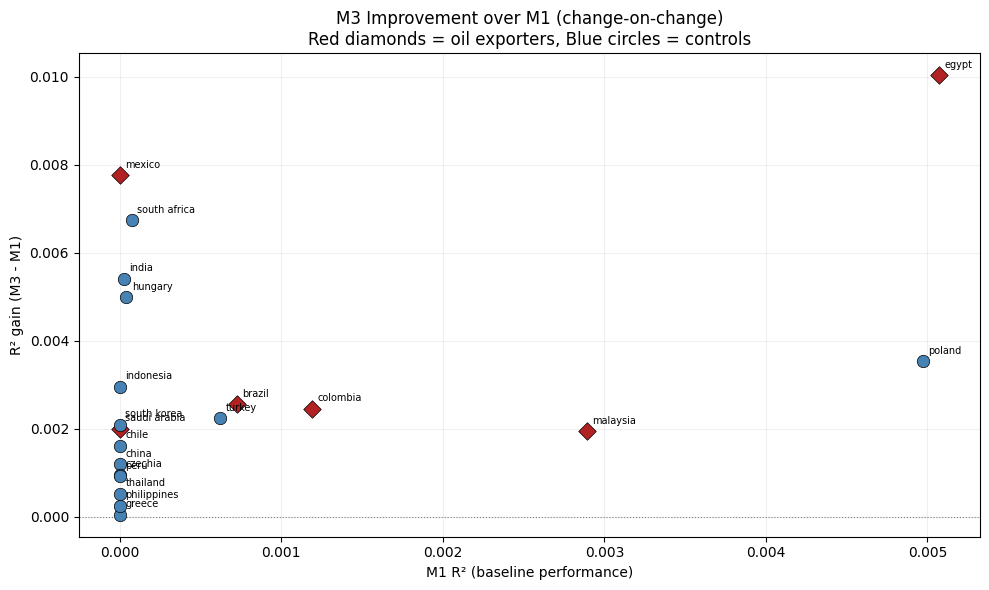

In [41]:
# ================================================================
# SCATTER: R² gain (M3 vs M1) by country
# ================================================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in cc_df.iterrows():
    if np.isnan(row.get('R2_gain', np.nan)):
        continue
    oil = row['oil_exporter']
    color = 'firebrick' if oil == 1 else 'steelblue'
    marker = 'D' if oil == 1 else 'o'
    ax.scatter(row['R2_M1'], row['R2_gain'], c=color, marker=marker,
               s=80, edgecolors='k', linewidth=0.5, zorder=3)
    ax.annotate(row['country'], (row['R2_M1'], row['R2_gain']),
                fontsize=7, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('M1 R² (baseline performance)')
ax.set_ylabel('R² gain (M3 - M1)')
ax.set_title('M3 Improvement over M1 (change-on-change)\n'
             'Red diamonds = oil exporters, Blue circles = controls')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [42]:
# ================================================================
# IDENTIFY OVX STRESS EPISODES
# ================================================================
# An episode = contiguous run of weeks where OVX >= threshold.
# We also include a buffer: N weeks before (lead-in) and N weeks
# after (aftermath) to capture the full CDS response.
# ================================================================

OVX_THRESHOLD = df_res['OVX'].quantile(0.80)   # top 20% of OVX
BUFFER_WEEKS  = 4                                # weeks before/after

print(f'OVX stress threshold (p80): {OVX_THRESHOLD:.1f}')

# Build a global OVX series (one row per date)
ovx_dates = (df_res[['date', 'OVX']]
             .drop_duplicates('date')
             .sort_values('date')
             .reset_index(drop=True))
ovx_dates['stress'] = (ovx_dates['OVX'] >= OVX_THRESHOLD).astype(int)

# Identify contiguous stress runs
ovx_dates['episode_id'] = (ovx_dates['stress'].diff().ne(0).cumsum()
                            * ovx_dates['stress'])
episodes_raw = (ovx_dates[ovx_dates['episode_id'] > 0]
                .groupby('episode_id')
                .agg(start=('date', 'min'), end=('date', 'max'),
                     n_weeks=('date', 'count'),
                     avg_ovx=('OVX', 'mean'), max_ovx=('OVX', 'max'))
                .reset_index(drop=True))

# Only keep episodes >= 2 weeks
episodes = episodes_raw[episodes_raw['n_weeks'] >= 2].copy()

# Add buffer
episodes['window_start'] = episodes['start'] - pd.Timedelta(weeks=BUFFER_WEEKS)
episodes['window_end']   = episodes['end']   + pd.Timedelta(weeks=BUFFER_WEEKS)

print(f'\nFound {len(episodes)} stress episodes (>= 2 weeks):')
print('-' * 70)
for _, ep in episodes.iterrows():
    print(f'  {ep["start"].strftime("%Y-%m-%d")} to {ep["end"].strftime("%Y-%m-%d")}  '
          f'({ep["n_weeks"]:>2d} wks)  '
          f'avg OVX={ep["avg_ovx"]:.0f}  max={ep["max_ovx"]:.0f}')

# Flag rows that fall inside an episode window
df_res['in_episode'] = False
df_res['episode_id'] = np.nan
for i, ep in episodes.iterrows():
    mask = (df_res['date'] >= ep['window_start']) & (df_res['date'] <= ep['window_end'])
    df_res.loc[mask, 'in_episode'] = True
    df_res.loc[mask, 'episode_id'] = i

n_in  = df_res['in_episode'].sum()
n_out = (~df_res['in_episode']).sum()
print(f'\nPanel rows in episodes: {n_in} ({n_in/(n_in+n_out)*100:.0f}%)')
print(f'Panel rows outside:     {n_out} ({n_out/(n_in+n_out)*100:.0f}%)')


OVX stress threshold (p80): 46.6

Found 15 stress episodes (>= 2 weeks):
----------------------------------------------------------------------
  2014-12-12 to 2015-04-03  (17 wks)  avg OVX=54  max=61
  2015-08-28 to 2015-09-11  ( 3 wks)  avg OVX=50  max=52
  2015-12-11 to 2015-12-18  ( 2 wks)  avg OVX=52  max=54
  2016-01-08 to 2016-03-11  (10 wks)  avg OVX=61  max=79
  2016-04-01 to 2016-04-15  ( 3 wks)  avg OVX=49  max=51
  2018-11-23 to 2018-11-30  ( 2 wks)  avg OVX=61  max=65
  2018-12-21 to 2019-01-04  ( 3 wks)  avg OVX=52  max=53
  2020-02-28 to 2020-07-10  (20 wks)  avg OVX=97  max=190
  2020-10-30 to 2020-11-13  ( 3 wks)  avg OVX=58  max=69
  2021-11-26 to 2021-12-03  ( 2 wks)  avg OVX=65  max=66
  2022-02-11 to 2022-05-27  (16 wks)  avg OVX=56  max=77
  2022-06-17 to 2022-07-22  ( 6 wks)  avg OVX=50  max=52
  2022-08-19 to 2022-11-04  (12 wks)  avg OVX=50  max=56
  2023-03-17 to 2023-03-24  ( 2 wks)  avg OVX=50  max=51
  2024-10-11 to 2024-10-25  ( 3 wks)  avg OVX=50  max=53


In [43]:
# ================================================================
# FULL SAMPLE vs EPISODE PERFORMANCE
# ================================================================
# Report change-on-change R2 for M1 and M3, split by:
#   - full sample vs episodes only
#   - oil exporters vs controls
# ================================================================

import statsmodels.api as sm

df_s = df_res.sort_values(['country_clean', 'date']).copy()
df_s['d_cds']       = df_s.groupby('country_clean')['cds_spread'].diff()
df_s['d_spread_m1'] = df_s.groupby('country_clean')['spread_m1'].diff()
df_s['d_spread_m3'] = df_s.groupby('country_clean')['spread_m3'].diff()

def compute_r2(subset, model_col):
    """Change-on-change R2 for a given subset and model."""
    tmp = subset[['d_cds', model_col, 'country_clean']].dropna()
    if len(tmp) < 30:
        return np.nan, np.nan, np.nan, 0
    y = tmp['d_cds'].values
    X = sm.add_constant(tmp[model_col].values)
    reg = sm.OLS(y, X).fit(cov_type='cluster',
                           cov_kwds={'groups': tmp['country_clean'].values})
    return reg.rsquared, reg.params[1], reg.pvalues[1], int(reg.nobs)

# ---- Table ----
print('=' * 85)
print('  CHANGE-ON-CHANGE R2: FULL SAMPLE vs OVX EPISODES')
print('  dCDS(t) = a + b * dSpread_model(t) + e')
print('=' * 85)
print(f'\n{"Sample":<30s} {"Group":<18s} {"R2_M1":>7s} {"R2_M3":>7s} '
      f'{"R2 gain":>8s} {"N":>6s}')
print('-' * 85)

for sample_label, sample_mask in [('Full sample', df_s.index == df_s.index),
                                   ('OVX episodes only', df_s['in_episode']),
                                   ('Outside episodes', ~df_s['in_episode'])]:
    for grp, glabel in [(1, 'Oil Exporters'), (0, 'Controls'), (None, 'All')]:
        if grp is not None:
            mask = sample_mask & (df_s['oil_exporter'] == grp)
        else:
            mask = sample_mask & df_s['oil_exporter'].notna()
        sub = df_s[mask]

        r2_m1, b_m1, p_m1, n1 = compute_r2(sub, 'd_spread_m1')
        r2_m3, b_m3, p_m3, n3 = compute_r2(sub, 'd_spread_m3')
        gain = r2_m3 - r2_m1 if not np.isnan(r2_m1) else np.nan

        marker = ' ***' if not np.isnan(gain) and gain > 0.005 else ''
        print(f'  {sample_label:<28s} {glabel:<18s} {r2_m1:>7.4f} {r2_m3:>7.4f} '
              f'{gain:>+8.4f} {n1:>6d}{marker}')
    print()

print('  KEY: R2 gain > 0 during episodes for oil exporters = thesis result')
print('  *** marks gains > 0.005')


  CHANGE-ON-CHANGE R2: FULL SAMPLE vs OVX EPISODES
  dCDS(t) = a + b * dSpread_model(t) + e

Sample                         Group                R2_M1   R2_M3  R2 gain      N
-------------------------------------------------------------------------------------
  Full sample                  Oil Exporters       0.0014  0.0070  +0.0056   3126 ***
  Full sample                  Controls            0.0004  0.0018  +0.0014   4441
  Full sample                  All                 0.0011  0.0021  +0.0010   7567

  OVX episodes only            Oil Exporters       0.0019  0.0284  +0.0264   1044 ***
  OVX episodes only            Controls            0.0001  0.0093  +0.0092   1497 ***
  OVX episodes only            All                 0.0015  0.0102  +0.0087   2541 ***

  Outside episodes             Oil Exporters       0.0011  0.0001  -0.0010   2082
  Outside episodes             Controls            0.0008  0.0002  -0.0006   2944
  Outside episodes             All                 0.0010  0.0001

In [44]:
# ================================================================
# COUNTRY-LEVEL: R2 INSIDE vs OUTSIDE EPISODES
# ================================================================

print('=' * 90)
print('  COUNTRY-LEVEL: R2 IMPROVEMENT (M3 vs M1)')
print('=' * 90)
print(f'\n{"Country":<20s} {"Oil":>3s} '
      f'{"--- Full Sample ---":>22s}  {"-- OVX Episodes --":>22s}')
print(f'{"":20s} {"":>3s} '
      f'{"R2_M1":>7s} {"R2_M3":>7s} {"gain":>7s}  '
      f'{"R2_M1":>7s} {"R2_M3":>7s} {"gain":>7s}')
print('-' * 90)

country_rows = []
for ctry in sorted(df_s['country_clean'].unique()):
    dc_full = df_s[df_s['country_clean'] == ctry]
    dc_ep   = dc_full[dc_full['in_episode']]
    oil = dc_full['oil_exporter'].iloc[0]

    row = {'country': ctry, 'oil_exporter': oil}
    for suffix, subset in [('full', dc_full), ('ep', dc_ep)]:
        for model, mcol in [('M1', 'd_spread_m1'), ('M3', 'd_spread_m3')]:
            tmp = subset[[mcol, 'd_cds']].dropna()
            if len(tmp) < 20:
                row[f'R2_{model}_{suffix}'] = np.nan
                continue
            y = tmp['d_cds'].values
            X = sm.add_constant(tmp[mcol].values)
            try:
                reg = sm.OLS(y, X).fit()
                row[f'R2_{model}_{suffix}'] = reg.rsquared
            except Exception:
                row[f'R2_{model}_{suffix}'] = np.nan

    row['gain_full'] = (row.get('R2_M3_full', np.nan) or np.nan) - (row.get('R2_M1_full', np.nan) or np.nan)
    row['gain_ep']   = (row.get('R2_M3_ep', np.nan) or np.nan) - (row.get('R2_M1_ep', np.nan) or np.nan)
    country_rows.append(row)

    tag = 'OIL' if oil == 1 else 'CTL'
    g_f = f'{row["gain_full"]:>+7.4f}' if not np.isnan(row.get('gain_full', np.nan)) else '     --'
    g_e = f'{row["gain_ep"]:>+7.4f}' if not np.isnan(row.get('gain_ep', np.nan)) else '     --'
    r1f = f'{row.get("R2_M1_full", np.nan):>7.4f}' if not np.isnan(row.get('R2_M1_full', np.nan)) else '     --'
    r3f = f'{row.get("R2_M3_full", np.nan):>7.4f}' if not np.isnan(row.get('R2_M3_full', np.nan)) else '     --'
    r1e = f'{row.get("R2_M1_ep", np.nan):>7.4f}' if not np.isnan(row.get('R2_M1_ep', np.nan)) else '     --'
    r3e = f'{row.get("R2_M3_ep", np.nan):>7.4f}' if not np.isnan(row.get('R2_M3_ep', np.nan)) else '     --'
    print(f'  {ctry:<20s} [{tag}] {r1f} {r3f} {g_f}  {r1e} {r3e} {g_e}')

cdf = pd.DataFrame(country_rows)

# Group averages
print('\n' + '-' * 90)
for grp, label in [(1, 'Oil Exporters'), (0, 'Controls')]:
    sub = cdf[cdf['oil_exporter'] == grp]
    g_f = sub['gain_full'].mean()
    g_e = sub['gain_ep'].mean()
    print(f'  {label} (n={len(sub)}):  '
          f'avg gain (full)={g_f:+.4f}  avg gain (episodes)={g_e:+.4f}  '
          f'ratio={g_e/g_f:.1f}x' if g_f != 0 else
          f'  {label} (n={len(sub)}):  '
          f'avg gain (full)={g_f:+.4f}  avg gain (episodes)={g_e:+.4f}')

print('\n  THESIS TEST: gain_ep should be larger than gain_full,')
print('  and this difference should be bigger for oil exporters.')


  COUNTRY-LEVEL: R2 IMPROVEMENT (M3 vs M1)

Country              Oil    --- Full Sample ---      -- OVX Episodes --
                           R2_M1   R2_M3    gain    R2_M1   R2_M3    gain
------------------------------------------------------------------------------------------
  brazil               [OIL]  0.0007  0.0033 +0.0026   0.0001  0.0159 +0.0159
  chile                [CTL]  0.0000  0.0016 +0.0016   0.0000  0.0117 +0.0117
  china                [CTL]  0.0000  0.0012 +0.0012   0.0000  0.0032      --
  colombia             [OIL]  0.0012  0.0036 +0.0024   0.0013  0.0223 +0.0210
  czechia              [CTL]  0.0000  0.0010 +0.0010   0.0000  0.0115      --
  egypt                [OIL]  0.0051  0.0151 +0.0100   0.0112  0.0518 +0.0406
  greece               [CTL]  0.0000  0.0000 +0.0000   0.0002  0.0011 +0.0008
  hungary              [CTL]  0.0000  0.0050 +0.0050   0.0000  0.0290 +0.0290
  india                [CTL]  0.0000  0.0054 +0.0054   0.0001  0.0024 +0.0023
  indonesia      

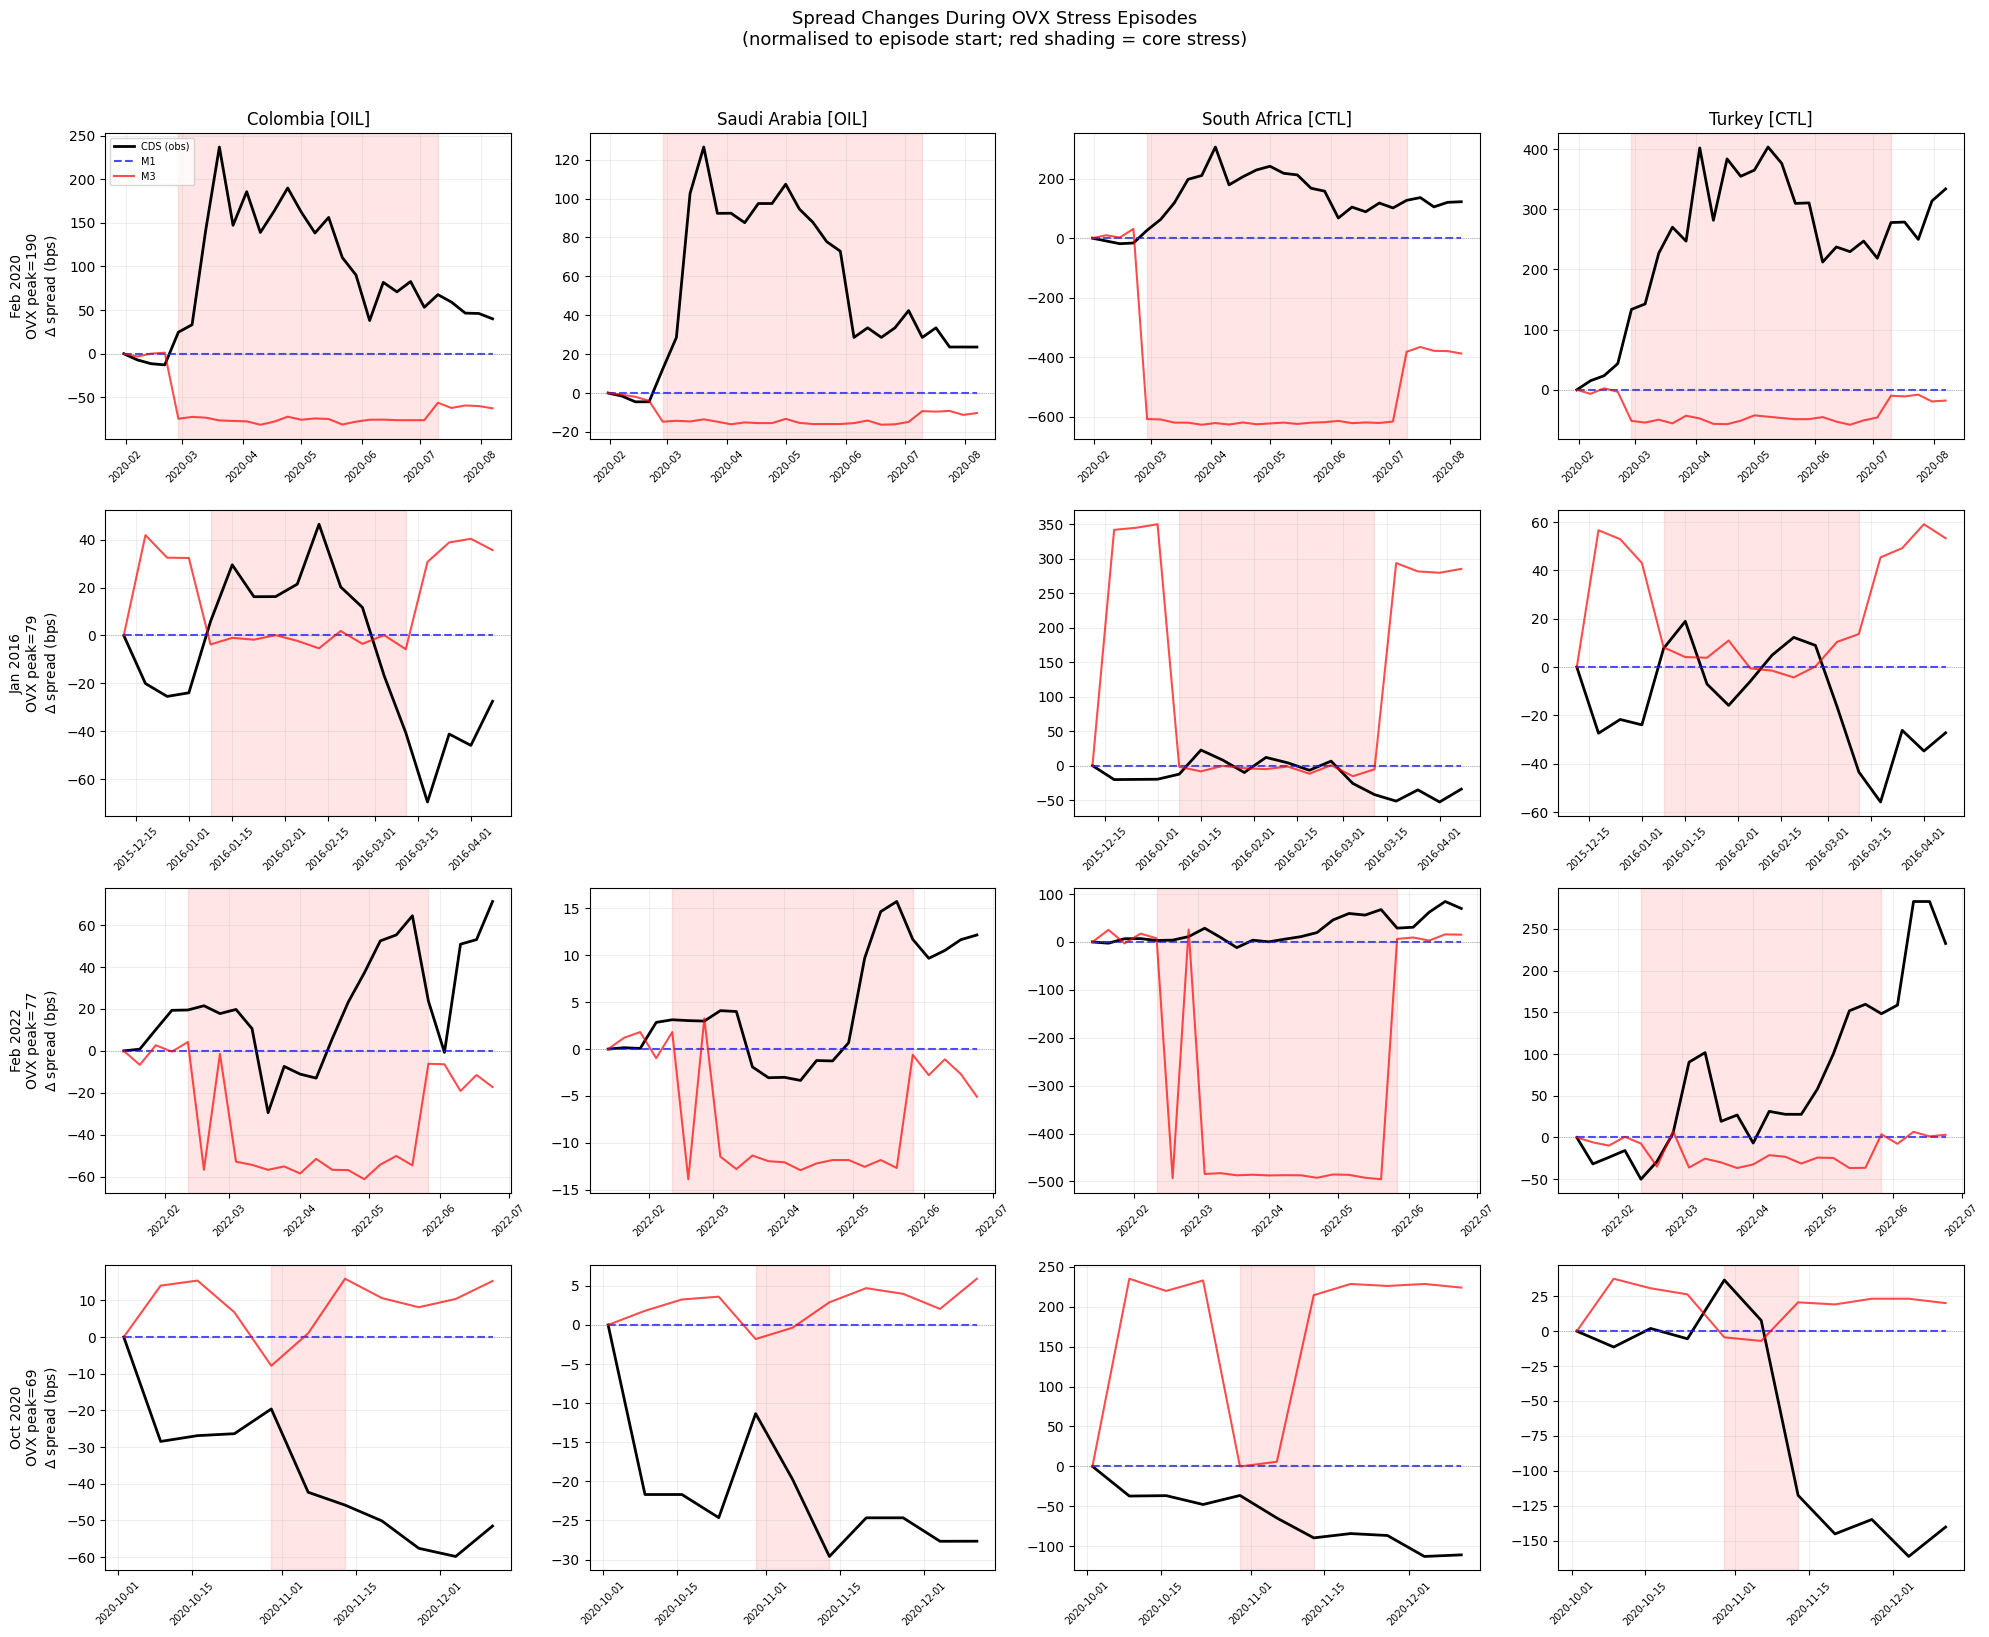

In [45]:
# ================================================================
# EPISODE ZOOM: CDS vs MODEL SPREADS DURING STRESS
# ================================================================

# Pick the largest episodes
top_episodes = episodes.nlargest(min(4, len(episodes)), 'max_ovx')

showcase_countries = ['colombia', 'saudi arabia', 'south africa', 'turkey']

fig, axes = plt.subplots(len(top_episodes), len(showcase_countries),
                         figsize=(5*len(showcase_countries),
                                  4*len(top_episodes)),
                         squeeze=False)

for row_i, (_, ep) in enumerate(top_episodes.iterrows()):
    for col_j, ctry in enumerate(showcase_countries):
        ax = axes[row_i, col_j]

        dc = df_s[(df_s['country_clean'].str.lower() == ctry) &
                  (df_s['date'] >= ep['window_start']) &
                  (df_s['date'] <= ep['window_end'])].sort_values('date')

        if len(dc) < 3:
            ax.set_visible(False)
            continue

        # Normalise to start of window for visual comparison
        cds_base = dc['cds_spread'].iloc[0]
        m1_base  = dc['spread_m1'].iloc[0]
        m3_base  = dc['spread_m3'].iloc[0]

        ax.plot(dc['date'], dc['cds_spread'] - cds_base,
                'k-', lw=2, label='CDS (obs)')
        ax.plot(dc['date'], dc['spread_m1'] - m1_base,
                'b--', lw=1.5, label='M1', alpha=0.7)
        ax.plot(dc['date'], dc['spread_m3'] - m3_base,
                'r-', lw=1.5, label='M3', alpha=0.7)

        # Shade core stress period
        ax.axvspan(ep['start'], ep['end'], alpha=0.1, color='red')

        ax.axhline(0, color='gray', lw=0.5, ls=':')

        oil = dc['oil_exporter'].iloc[0]
        tag = 'OIL' if oil == 1 else 'CTL'
        if row_i == 0:
            ax.set_title(f'{ctry.title()} [{tag}]')
        if col_j == 0:
            ax.set_ylabel(f'{ep["start"].strftime("%b %Y")}\n'
                          f'OVX peak={ep["max_ovx"]:.0f}\n'
                          r'$\Delta$ spread (bps)')
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7, loc='upper left')

        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.grid(True, alpha=0.2)

plt.suptitle('Spread Changes During OVX Stress Episodes\n'
             '(normalised to episode start; red shading = core stress)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [46]:
# ================================================================
# CROSS-COUNTRY MODEL COMPARISON
# ================================================================

print('Cross-Country Model Comparison')
print('=' * 85)
print(f'{"country":>15s} {"oil":>4s} {"avg_cds":>8s} {"rating":>6s} {"scale":>6s} '
      f'{"rmse_m1":>8s} {"rmse_m3":>8s} {"rmse_improv":>11s}')
print('-' * 85)

for ctry in sorted(df_res['country_clean'].unique()):
    dc = df_res[df_res['country_clean'] == ctry]
    oil = dc['oil_exporter'].iloc[0]
    rating = dc['sp_rating'].iloc[0] if 'sp_rating' in dc.columns else '?'
    avg_cds = dc['cds_spread'].mean()
    avg_scale = dc['scale_rating'].mean() if 'scale_rating' in dc.columns else np.nan

    obs = dc['cds_spread'].values
    rmse_m1 = np.sqrt(np.mean((obs - dc['spread_m1'].values)**2))
    rmse_m3 = np.sqrt(np.mean((obs - dc['spread_m3'].values)**2))
    improv = rmse_m1 - rmse_m3

    tag = 'OIL' if oil == 1 else 'CTL'
    print(f'{ctry:>15s} [{tag}] {avg_cds:>8.1f} {str(rating):>6s} {avg_scale:>6.2f} '
          f'{rmse_m1:>8.1f} {rmse_m3:>8.1f} {improv:>+11.1f}')


Cross-Country Model Comparison
        country  oil  avg_cds rating  scale  rmse_m1  rmse_m3 rmse_improv
-------------------------------------------------------------------------------------
         brazil [OIL]    214.4     BB   3.96    138.6    125.0       +13.6
          chile [CTL]     75.2      A   6.53     75.4     69.8        +5.6
          china [CTL]     60.7     A+   5.48     61.4     60.4        +1.0
       colombia [OIL]    163.4    BB+   6.06    109.8     91.7       +18.1
        czechia [CTL]     41.2    AA-   6.78     40.4     38.0        +2.4
          egypt [OIL]    537.4     B-   2.05    385.0    365.3       +19.8
         greece [CTL]   3152.7   BBB-   6.97  10030.6  10029.5        +1.1
        hungary [CTL]    121.7   BBB-   3.95     87.6     74.5       +13.1
          india [CTL]     94.2   BBB-   2.24     53.2     40.5       +12.7
      indonesia [CTL]    121.1    BBB   3.82    107.3    100.1        +7.2
       malaysia [OIL]     69.2     A-   2.24     67.8     6

In [49]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# ================================================================
# PANEL PREPARATION
# ================================================================
# Assumes df_res exists from notebook 08.
# Adjust column names below if your panel uses different names.

df = df_res.sort_values(['country_clean', 'date']).copy()

# ---- Weekly changes (first-differences) ----
for col in ['cds_spread', 'spread_m1', 'spread_m3', 'dd_m1', 'dd_m3']:
    df[f'd_{col}'] = df.groupby('country_clean')[col].diff()

# ---- The jump increment: what jumps ADD to the model ----
# This is the key variable. It measures how much the jump model's
# DD or spread differs from the baseline, and how that changes week-to-week.
df['dd_jump_increment']  = df['dd_m3'] - df['dd_m1']       # level: always <= 0
df['d_dd_jump_increment'] = df.groupby('country_clean')['dd_jump_increment'].diff()
df['d_spread_jump_incr']  = df['d_spread_m3'] - df['d_spread_m1']

# ---- OVX regime indicator ----
OVX_P75 = df['OVX'].quantile(0.75)
df['high_ovx'] = (df['OVX'] >= OVX_P75).astype(int)
print(f'OVX 75th percentile threshold: {OVX_P75:.1f}')
print(f'High-OVX weeks: {df["high_ovx"].sum()} / {len(df)} '
      f'({df["high_ovx"].mean()*100:.0f}%)')

# ---- Auto-detect control variables ----
# Common controls in sovereign CDS panels. We check which exist.
CANDIDATE_CONTROLS = [
    'vix', 'VIX', 'd_vix', 'vix_change',
    'us_10y', 'd_us10y', 'us_treasury_10y',
    'msci_world_ret', 'msci_em_ret', 'msci_ret',
    'fx_ret', 'fx_return', 'd_fx',
    'brent_ret', 'oil_ret', 'brent_return',
    'embi_spread', 'd_embi',
]

available_controls = [c for c in CANDIDATE_CONTROLS if c in df.columns]
print(f'\nAvailable control variables: {available_controls}')
print(f'Countries: {sorted(df["country_clean"].unique())}')
print(f'Oil exporters: {sorted(df[df["oil_exporter"]==1]["country_clean"].unique())}')
print(f'Controls:      {sorted(df[df["oil_exporter"]==0]["country_clean"].unique())}')

# ---- Drop rows with missing key variables ----
key_cols = ['d_cds_spread', 'd_dd_m1', 'd_dd_m3', 'd_dd_jump_increment',
            'oil_exporter', 'high_ovx']
df_clean = df.dropna(subset=key_cols).copy()
print(f'\nClean panel: {len(df_clean)} obs, '
      f'{df_clean["country_clean"].nunique()} countries')

OVX 75th percentile threshold: 43.9
High-OVX weeks: 2741 / 10961 (25%)

Available control variables: []
Countries: ['brazil', 'chile', 'china', 'colombia', 'czechia', 'egypt', 'greece', 'hungary', 'india', 'indonesia', 'malaysia', 'mexico', 'peru', 'philippines', 'poland', 'saudi arabia', 'south africa', 'south korea', 'thailand', 'turkey']
Oil exporters: ['brazil', 'colombia', 'egypt', 'malaysia', 'mexico', 'saudi arabia']
Controls:      ['chile', 'china', 'indonesia', 'philippines', 'south africa', 'south korea', 'thailand', 'turkey']

Clean panel: 7567 obs, 14 countries


In [50]:
# ================================================================
# APPROACH 1: NESTED CHANGE-ON-CHANGE
# ================================================================

print('=' * 80)
print('  APPROACH 1: NESTED CHANGE-ON-CHANGE REGRESSIONS')
print('  ΔCDS = α_i + β₁·ΔDD_baseline + β₂·ΔDD_jump_increment + controls + ε')
print('=' * 80)

# --- 1A. Simple nested test: does the jump increment add info? ---
print('\n--- 1A. Baseline: does the jump increment add information? ---\n')

# Prepare control string for formulas
ctrl_str = ' + '.join(available_controls) if available_controls else ''

# Model A1: Baseline only
fml_base = 'd_cds_spread ~ d_dd_m1'
if ctrl_str:
    fml_base += ' + ' + ctrl_str
fml_base += ' + C(country_clean)'

# Model A2: Baseline + jump increment
fml_nested = 'd_cds_spread ~ d_dd_m1 + d_dd_jump_increment'
if ctrl_str:
    fml_nested += ' + ' + ctrl_str
fml_nested += ' + C(country_clean)'

reg_base = smf.ols(fml_base, data=df_clean).fit(
    cov_type='cluster', cov_kwds={'groups': df_clean['country_clean']})
reg_nested = smf.ols(fml_nested, data=df_clean).fit(
    cov_type='cluster', cov_kwds={'groups': df_clean['country_clean']})

print('Model A1 (baseline DD only):')
print(f'  R² = {reg_base.rsquared:.4f},  N = {int(reg_base.nobs)}')
b1 = reg_base.params.get('d_dd_m1', np.nan)
t1 = reg_base.tvalues.get('d_dd_m1', np.nan)
p1 = reg_base.pvalues.get('d_dd_m1', np.nan)
print(f'  β(ΔDD_baseline) = {b1:.4f}  [t = {t1:.2f}, p = {p1:.4f}]')

print('\nModel A2 (baseline DD + jump increment):')
print(f'  R² = {reg_nested.rsquared:.4f},  N = {int(reg_nested.nobs)}')
b1n = reg_nested.params.get('d_dd_m1', np.nan)
t1n = reg_nested.tvalues.get('d_dd_m1', np.nan)
p1n = reg_nested.pvalues.get('d_dd_m1', np.nan)
b2  = reg_nested.params.get('d_dd_jump_increment', np.nan)
t2  = reg_nested.tvalues.get('d_dd_jump_increment', np.nan)
p2  = reg_nested.pvalues.get('d_dd_jump_increment', np.nan)
print(f'  β(ΔDD_baseline)  = {b1n:.4f}  [t = {t1n:.2f}, p = {p1n:.4f}]')
print(f'  β(ΔDD_jump_incr) = {b2:.4f}  [t = {t2:.2f}, p = {p2:.4f}]')
print(f'\n  R² improvement: {reg_nested.rsquared - reg_base.rsquared:+.4f}')

# F-test for nested model (is the jump increment jointly significant?)
from statsmodels.stats.anova import anova_lm
try:
    # Re-fit without cluster for proper F-test
    reg_base_ols = smf.ols(fml_base, data=df_clean).fit()
    reg_nested_ols = smf.ols(fml_nested, data=df_clean).fit()
    f_test = anova_lm(reg_base_ols, reg_nested_ols)
    f_stat = f_test['F'].iloc[1]
    f_pval = f_test['Pr(>F)'].iloc[1]
    print(f'  F-test (jump increment = 0): F = {f_stat:.2f}, p = {f_pval:.4f}')
except Exception as e:
    print(f'  (F-test skipped: {e})')

  APPROACH 1: NESTED CHANGE-ON-CHANGE REGRESSIONS
  ΔCDS = α_i + β₁·ΔDD_baseline + β₂·ΔDD_jump_increment + controls + ε

--- 1A. Baseline: does the jump increment add information? ---

Model A1 (baseline DD only):
  R² = 0.0000,  N = 7567
  β(ΔDD_baseline) = -0.0000  [t = -8390552020086.77, p = 0.0000]

Model A2 (baseline DD + jump increment):
  R² = 0.0012,  N = 7567
  β(ΔDD_baseline)  = 0.0000  [t = 2.50, p = 0.0124]
  β(ΔDD_jump_incr) = 3.1059  [t = 2.39, p = 0.0170]

  R² improvement: +0.0012
  F-test (jump increment = 0): F = 8.91, p = 0.0028


In [51]:
# --- 1B. DiD: Is the jump increment more useful for oil exporters? ---
print('\n' + '=' * 80)
print('--- 1B. DiD: Jump increment × Oil Exporter × High OVX ---')
print('=' * 80)

# Full interaction model
fml_did = ('d_cds_spread ~ d_dd_m1 '
           '+ d_dd_jump_increment '
           '+ d_dd_jump_increment : oil_exporter '
           '+ d_dd_jump_increment : high_ovx '
           '+ d_dd_jump_increment : oil_exporter : high_ovx')
if ctrl_str:
    fml_did += ' + ' + ctrl_str
fml_did += ' + C(country_clean)'

reg_did = smf.ols(fml_did, data=df_clean).fit(
    cov_type='cluster', cov_kwds={'groups': df_clean['country_clean']})

print(f'\nR² = {reg_did.rsquared:.4f},  N = {int(reg_did.nobs)}\n')

# Extract and display the key coefficients
key_vars = ['d_dd_m1', 'd_dd_jump_increment',
            'd_dd_jump_increment:oil_exporter',
            'd_dd_jump_increment:high_ovx',
            'd_dd_jump_increment:oil_exporter:high_ovx']

print(f'  {"Variable":<50s} {"Coef":>8s} {"t":>7s} {"p":>7s}  {"Sig":>3s}')
print('  ' + '-' * 80)
for var in key_vars:
    if var in reg_did.params.index:
        coef = reg_did.params[var]
        tval = reg_did.tvalues[var]
        pval = reg_did.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        print(f'  {var:<50s} {coef:>8.4f} {tval:>7.2f} {pval:>7.4f}  {sig:>3s}')

# --- Interpretation guide ---
print('\n  INTERPRETATION:')
print('  β(ΔDD_jump_incr)               = effect of jumps for controls in low OVX')
print('  β(... × oil_exporter)           = additional effect for oil exporters')
print('  β(... × high_ovx)               = additional effect during high OVX')
print('  β(... × oil_exporter × high_ovx)= DiD: extra effect for oil exp. in high OVX')
print('  → THESIS HYPOTHESIS: last coefficient should be significant')


--- 1B. DiD: Jump increment × Oil Exporter × High OVX ---

R² = 0.0059,  N = 7567

  Variable                                               Coef       t       p  Sig
  --------------------------------------------------------------------------------
  d_dd_m1                                              0.0000    2.57  0.0103   **
  d_dd_jump_increment                                 -0.5046   -1.22  0.2214     
  d_dd_jump_increment:oil_exporter                    -0.2097   -0.43  0.6659     
  d_dd_jump_increment:high_ovx                         5.4490    1.95  0.0516    *
  d_dd_jump_increment:oil_exporter:high_ovx           15.3910    1.25  0.2101     

  INTERPRETATION:
  β(ΔDD_jump_incr)               = effect of jumps for controls in low OVX
  β(... × oil_exporter)           = additional effect for oil exporters
  β(... × high_ovx)               = additional effect during high OVX
  β(... × oil_exporter × high_ovx)= DiD: extra effect for oil exp. in high OVX
  → THESIS HYPOTHESI

In [52]:
# --- 1C. Split-sample: run separately for oil exporters vs controls ---
print('\n' + '=' * 80)
print('--- 1C. Split-Sample Regressions ---')
print('=' * 80)

for grp, label in [(1, 'Oil Exporters'), (0, 'Controls')]:
    sub = df_clean[df_clean['oil_exporter'] == grp]
    if len(sub) < 50:
        print(f'\n  {label}: insufficient data (n={len(sub)})')
        continue

    for regime, rlabel in [('all', 'Full Sample'),
                            ('high', 'High OVX Only'),
                            ('low', 'Low OVX Only')]:
        if regime == 'high':
            ss = sub[sub['high_ovx'] == 1]
        elif regime == 'low':
            ss = sub[sub['high_ovx'] == 0]
        else:
            ss = sub

        if len(ss) < 30:
            continue

        fml = 'd_cds_spread ~ d_dd_m1 + d_dd_jump_increment'
        if ctrl_str:
            fml += ' + ' + ctrl_str
        fml += ' + C(country_clean)'

        try:
            reg = smf.ols(fml, data=ss).fit(
                cov_type='cluster', cov_kwds={'groups': ss['country_clean']})

            b_base = reg.params.get('d_dd_m1', np.nan)
            b_jump = reg.params.get('d_dd_jump_increment', np.nan)
            t_jump = reg.tvalues.get('d_dd_jump_increment', np.nan)
            p_jump = reg.pvalues.get('d_dd_jump_increment', np.nan)
            sig = '***' if p_jump < 0.01 else '**' if p_jump < 0.05 else '*' if p_jump < 0.1 else ''

            print(f'\n  {label:<18s} | {rlabel:<16s} | N={int(reg.nobs):>5d} | R²={reg.rsquared:.4f}')
            print(f'    β(ΔDD_base)={b_base:>8.4f}   β(ΔDD_jump)={b_jump:>8.4f} '
                  f'[t={t_jump:.2f}, p={p_jump:.4f}] {sig}')
        except Exception as e:
            print(f'\n  {label:<18s} | {rlabel:<16s} | ERROR: {e}')


--- 1C. Split-Sample Regressions ---

  Oil Exporters      | Full Sample      | N= 3126 | R²=0.0021
    β(ΔDD_base)=  0.0000   β(ΔDD_jump)=  6.7192 [t=1.59, p=0.1111] 

  Oil Exporters      | High OVX Only    | N=  773 | R²=0.0148
    β(ΔDD_base)=  0.0000   β(ΔDD_jump)= 19.5538 [t=1.61, p=0.1070] 

  Oil Exporters      | Low OVX Only     | N= 2353 | R²=0.0013
    β(ΔDD_base)=  0.0000   β(ΔDD_jump)= -0.8353 [t=-2.62, p=0.0088] ***

  Controls           | Full Sample      | N= 4441 | R²=0.0010
    β(ΔDD_base)=  0.0000   β(ΔDD_jump)=  1.6596 [t=1.62, p=0.1062] 

  Controls           | High OVX Only    | N= 1113 | R²=0.0073
    β(ΔDD_base)=  0.0000   β(ΔDD_jump)=  4.7218 [t=1.66, p=0.0965] *

  Controls           | Low OVX Only     | N= 3328 | R²=0.0008
    β(ΔDD_base)= -0.0000   β(ΔDD_jump)= -0.5678 [t=-1.34, p=0.1798] 


In [53]:
# ================================================================
# APPROACH 3: RESIDUAL-BASED TEST
# ================================================================

print('\n' + '=' * 80)
print('  APPROACH 3: RESIDUAL-BASED TEST')
print('  Step 1: Strip standard risk factors from ΔCDS')
print('  Step 2: Test if the jump signal explains the residual')
print('=' * 80)

# ---- Stage 1: Factor model for CDS changes ----
# We build a standard factor model. If you have specific control columns,
# adjust the list below. The code auto-detects what's available.

# Also construct some controls from what we know exists in the panel
if 'OVX' in df_clean.columns:
    df_clean['d_ovx'] = df_clean.groupby('country_clean')['OVX'].diff()
if 'msci_vol_annual' in df_clean.columns:
    df_clean['d_msci_vol'] = df_clean.groupby('country_clean')['msci_vol_annual'].diff()

# Re-check controls including the ones we just created
all_possible = available_controls + ['d_ovx', 'd_msci_vol']
stage1_controls = [c for c in all_possible if c in df_clean.columns
                   and df_clean[c].notna().sum() > len(df_clean) * 0.5]

print(f'\nStage 1 controls: {stage1_controls}')

if not stage1_controls:
    print('\n  WARNING: No control variables found in the panel!')
    print('  The residual-based test works best with controls like:')
    print('  VIX changes, US Treasury changes, MSCI returns, FX returns, etc.')
    print('  Proceeding with country FE only (results will be weaker).\n')

# Build Stage 1 formula
if stage1_controls:
    ctrl_s1 = ' + '.join(stage1_controls)
    fml_s1 = f'd_cds_spread ~ {ctrl_s1} + C(country_clean)'
else:
    fml_s1 = 'd_cds_spread ~ C(country_clean)'

# Drop NAs for the stage 1 regression
s1_cols = ['d_cds_spread', 'country_clean', 'oil_exporter', 'high_ovx',
           'd_dd_jump_increment', 'dd_jump_increment'] + stage1_controls
df_s1 = df_clean.dropna(subset=[c for c in s1_cols if c in df_clean.columns]).copy()

print(f'Stage 1 sample: {len(df_s1)} obs')

reg_s1 = smf.ols(fml_s1, data=df_s1).fit(
    cov_type='cluster', cov_kwds={'groups': df_s1['country_clean']})

print(f'Stage 1 R² = {reg_s1.rsquared:.4f}  (variance explained by standard factors)')

# Print factor coefficients
print(f'\n  {"Factor":<25s} {"Coef":>8s} {"t":>7s} {"p":>7s}')
print('  ' + '-' * 52)
for var in stage1_controls:
    if var in reg_s1.params.index:
        print(f'  {var:<25s} {reg_s1.params[var]:>8.4f} '
              f'{reg_s1.tvalues[var]:>7.2f} {reg_s1.pvalues[var]:>7.4f}')

# Extract residuals
df_s1['resid_cds'] = reg_s1.resid

print(f'\n  Residual std: {df_s1["resid_cds"].std():.2f} bps')
print(f'  This is the CDS variation NOT explained by standard factors.')


  APPROACH 3: RESIDUAL-BASED TEST
  Step 1: Strip standard risk factors from ΔCDS
  Step 2: Test if the jump signal explains the residual

Stage 1 controls: ['d_ovx', 'd_msci_vol']
Stage 1 sample: 7553 obs
Stage 1 R² = 0.0416  (variance explained by standard factors)

  Factor                        Coef       t       p
  ----------------------------------------------------
  d_ovx                       0.5000    5.00  0.0000
  d_msci_vol                 96.3779    2.00  0.0459

  Residual std: 20.18 bps
  This is the CDS variation NOT explained by standard factors.


In [54]:
# ---- Stage 2: Does the jump signal explain the residual? ----
print('\n' + '=' * 80)
print('  STAGE 2: Jump Signal → CDS Residual')
print('=' * 80)

# The jump signal: how much the jump model moves DD differently from baseline
# We use the CHANGE in the jump increment (week-to-week)
# Positive d_dd_jump_increment = jumps pushed DD up relative to baseline this week
# Negative = jumps pushed DD down (more distress) relative to baseline

print(f'\nJump signal (Δ[DD_M3 - DD_M1]) summary:')
print(df_s1['d_dd_jump_increment'].describe().to_string())

# --- 3A. Simple: does the jump signal explain the residual? ---
print('\n--- 3A. Unconditional: Jump signal → Residual ---')

fml_s2a = 'resid_cds ~ d_dd_jump_increment'
reg_s2a = smf.ols(fml_s2a, data=df_s1).fit(
    cov_type='cluster', cov_kwds={'groups': df_s1['country_clean']})

b = reg_s2a.params['d_dd_jump_increment']
t = reg_s2a.tvalues['d_dd_jump_increment']
p = reg_s2a.pvalues['d_dd_jump_increment']
sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
print(f'  β(jump_signal) = {b:.4f}  [t = {t:.2f}, p = {p:.4f}] {sig}')
print(f'  R² = {reg_s2a.rsquared:.4f}')

# --- 3B. Full DiD: Jump signal × Oil exporter × High OVX ---
print('\n--- 3B. DiD: Jump Signal × Oil Exporter × High OVX → Residual ---\n')

fml_s2b = ('resid_cds ~ d_dd_jump_increment '
           '+ d_dd_jump_increment : oil_exporter '
           '+ d_dd_jump_increment : high_ovx '
           '+ d_dd_jump_increment : oil_exporter : high_ovx '
           '+ oil_exporter + high_ovx + oil_exporter : high_ovx')

reg_s2b = smf.ols(fml_s2b, data=df_s1).fit(
    cov_type='cluster', cov_kwds={'groups': df_s1['country_clean']})

print(f'  R² = {reg_s2b.rsquared:.4f},  N = {int(reg_s2b.nobs)}\n')

key_vars_s2 = [
    'd_dd_jump_increment',
    'd_dd_jump_increment:oil_exporter',
    'd_dd_jump_increment:high_ovx',
    'd_dd_jump_increment:oil_exporter:high_ovx',
    'oil_exporter',
    'high_ovx',
    'oil_exporter:high_ovx',
]

print(f'  {"Variable":<50s} {"Coef":>8s} {"t":>7s} {"p":>7s}  {"Sig":>3s}')
print('  ' + '-' * 80)
for var in key_vars_s2:
    if var in reg_s2b.params.index:
        coef = reg_s2b.params[var]
        tval = reg_s2b.tvalues[var]
        pval = reg_s2b.pvalues[var]
        sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        print(f'  {var:<50s} {coef:>8.4f} {tval:>7.2f} {pval:>7.4f}  {sig:>3s}')

print('\n  INTERPRETATION:')
print('  β(jump_signal)                     = baseline effect (controls, low OVX)')
print('  β(... × oil_exporter)              = extra for oil exporters')
print('  β(... × high_ovx)                  = extra during stress')
print('  β(... × oil_exporter × high_ovx)   = DiD: THESIS HYPOTHESIS')
print('  → If significant: oil-calibrated jumps capture sovereign-specific')
print('    oil risk that standard risk factors miss.')


  STAGE 2: Jump Signal → CDS Residual

Jump signal (Δ[DD_M3 - DD_M1]) summary:
count    7553.000000
mean       -0.000714
std         0.224962
min        -3.166690
25%        -0.033065
50%         0.000000
75%         0.030662
max         3.513378

--- 3A. Unconditional: Jump signal → Residual ---
  β(jump_signal) = 1.9098  [t = 1.78, p = 0.0753] *
  R² = 0.0005

--- 3B. DiD: Jump Signal × Oil Exporter × High OVX → Residual ---

  R² = 0.0028,  N = 7553

  Variable                                               Coef       t       p  Sig
  --------------------------------------------------------------------------------
  d_dd_jump_increment                                  0.8166    2.67  0.0076  ***
  d_dd_jump_increment:oil_exporter                    -0.0265   -0.05  0.9562     
  d_dd_jump_increment:high_ovx                        -0.2314   -0.15  0.8770     
  d_dd_jump_increment:oil_exporter:high_ovx           10.3383    1.07  0.2851     
  oil_exporter                             

In [55]:
# --- 3C. Split-sample for robustness ---
print('\n' + '=' * 80)
print('--- 3C. Split-Sample: Jump Signal → Residual ---')
print('=' * 80)

for grp, label in [(1, 'Oil Exporters'), (0, 'Controls')]:
    sub = df_s1[df_s1['oil_exporter'] == grp]
    for regime, rlabel in [('all', 'Full Sample'),
                            ('high', 'High OVX'),
                            ('low', 'Low OVX')]:
        if regime == 'high':
            ss = sub[sub['high_ovx'] == 1]
        elif regime == 'low':
            ss = sub[sub['high_ovx'] == 0]
        else:
            ss = sub

        if len(ss) < 30:
            continue

        reg = smf.ols('resid_cds ~ d_dd_jump_increment', data=ss).fit(
            cov_type='cluster', cov_kwds={'groups': ss['country_clean']})

        b = reg.params.get('d_dd_jump_increment', np.nan)
        t = reg.tvalues.get('d_dd_jump_increment', np.nan)
        p = reg.pvalues.get('d_dd_jump_increment', np.nan)
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f'  {label:<18s} | {rlabel:<12s} | N={int(reg.nobs):>5d} '
              f'| R²={reg.rsquared:.4f} | β={b:>8.4f} [t={t:.2f}] {sig}')


--- 3C. Split-Sample: Jump Signal → Residual ---
  Oil Exporters      | Full Sample  | N= 3120 | R²=0.0010 | β=  4.6517 [t=1.26] 
  Oil Exporters      | High OVX     | N=  773 | R²=0.0040 | β= 10.8970 [t=1.09] 
  Oil Exporters      | Low OVX      | N= 2347 | R²=0.0000 | β=  0.7901 [t=2.01] **
  Controls           | Full Sample  | N= 4433 | R²=0.0002 | β=  0.7717 [t=0.93] 
  Controls           | High OVX     | N= 1113 | R²=0.0001 | β=  0.5852 [t=0.35] 
  Controls           | Low OVX      | N= 3320 | R²=0.0003 | β=  0.8166 [t=2.59] ***


In [56]:
# ================================================================
# COMBINED RESULTS TABLE
# ================================================================
print('\n' + '=' * 80)
print('  COMBINED RESULTS: Does the Jump Component Add Information?')
print('=' * 80)

print(f'\n  {"Test":<55s} {"β":>7s} {"t":>6s} {"p":>7s} {"Sig":>3s}')
print('  ' + '-' * 82)

rows = []

# Approach 1A: nested test
b = reg_nested.params.get('d_dd_jump_increment', np.nan)
t = reg_nested.tvalues.get('d_dd_jump_increment', np.nan)
p = reg_nested.pvalues.get('d_dd_jump_increment', np.nan)
sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
rows.append(('A1. Jump incr. (full panel, nested)', b, t, p, sig))

# Approach 1B: DiD
for var, nice in [
    ('d_dd_jump_increment', 'A1B. Jump incr. (baseline)'),
    ('d_dd_jump_increment:oil_exporter', 'A1B. ... × Oil Exporter'),
    ('d_dd_jump_increment:high_ovx', 'A1B. ... × High OVX'),
    ('d_dd_jump_increment:oil_exporter:high_ovx', 'A1B. ... × Oil × High OVX (DiD)')
]:
    if var in reg_did.params.index:
        rows.append((nice,
                      reg_did.params[var],
                      reg_did.tvalues[var],
                      reg_did.pvalues[var],
                      '***' if reg_did.pvalues[var] < 0.01
                      else '**' if reg_did.pvalues[var] < 0.05
                      else '*' if reg_did.pvalues[var] < 0.1 else ''))

# Approach 3A: residual, unconditional
b = reg_s2a.params['d_dd_jump_increment']
t = reg_s2a.tvalues['d_dd_jump_increment']
p = reg_s2a.pvalues['d_dd_jump_increment']
sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
rows.append(('A3. Jump signal → residual (unconditional)', b, t, p, sig))

# Approach 3B: DiD on residual
for var, nice in [
    ('d_dd_jump_increment', 'A3B. Jump signal → residual (baseline)'),
    ('d_dd_jump_increment:oil_exporter', 'A3B. ... × Oil Exporter'),
    ('d_dd_jump_increment:high_ovx', 'A3B. ... × High OVX'),
    ('d_dd_jump_increment:oil_exporter:high_ovx', 'A3B. ... × Oil × High OVX (DiD)')
]:
    if var in reg_s2b.params.index:
        rows.append((nice,
                      reg_s2b.params[var],
                      reg_s2b.tvalues[var],
                      reg_s2b.pvalues[var],
                      '***' if reg_s2b.pvalues[var] < 0.01
                      else '**' if reg_s2b.pvalues[var] < 0.05
                      else '*' if reg_s2b.pvalues[var] < 0.1 else ''))

for name, b, t, p, sig in rows:
    print(f'  {name:<55s} {b:>7.4f} {t:>6.2f} {p:>7.4f} {sig:>3s}')

print('\n  NOTE: DD is inversely related to CDS spreads.')
print('  A negative β on ΔDD_jump_incr means that when jumps push DD down')
print('  (more distress), CDS spreads increase — the expected sign.')


  COMBINED RESULTS: Does the Jump Component Add Information?

  Test                                                          β      t       p Sig
  ----------------------------------------------------------------------------------
  A1. Jump incr. (full panel, nested)                      3.1059   2.39  0.0170  **
  A1B. Jump incr. (baseline)                              -0.5046  -1.22  0.2214    
  A1B. ... × Oil Exporter                                 -0.2097  -0.43  0.6659    
  A1B. ... × High OVX                                      5.4490   1.95  0.0516   *
  A1B. ... × Oil × High OVX (DiD)                         15.3910   1.25  0.2101    
  A3. Jump signal → residual (unconditional)               1.9098   1.78  0.0753   *
  A3B. Jump signal → residual (baseline)                   0.8166   2.67  0.0076 ***
  A3B. ... × Oil Exporter                                 -0.0265  -0.05  0.9562    
  A3B. ... × High OVX                                     -0.2314  -0.15  0.8770    
  